In [179]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


In [1]:
#black list used: https://github.com/Boyle-Lab/Blacklist
#repeatmask from uscs
!wget http://hgdownload.soe.ucsc.edu/goldenPath/hg38/database/rmsk.txt.gz


--2025-03-05 02:46:00--  http://hgdownload.soe.ucsc.edu/goldenPath/hg38/database/rmsk.txt.gz
Resolving proxy1.arc-ts.umich.edu (proxy1.arc-ts.umich.edu)... 141.211.192.53
Connecting to proxy1.arc-ts.umich.edu (proxy1.arc-ts.umich.edu)|141.211.192.53|:3128... connected.
Proxy request sent, awaiting response... 200 OK
Length: 155633856 (148M) [application/x-gzip]
Saving to: ‘rmsk.txt.gz’

rmsk.txt.gz         100%[===================>] 148.42M  43.0MB/s    in 3.5s    

2025-03-05 02:46:05 (43.0 MB/s) - ‘rmsk.txt.gz’ saved [155633856/155633856]



In [45]:
!cut -f6,7,8,11,12,13 rmsk.txt > repeatmasker_hg38.bed

In [46]:
!head repeatmasker_hg38.bed

chr1	10000	10468	(TAACCC)n	Simple_repeat	Simple_repeat
chr1	10468	11447	TAR1	Satellite	telo
chr1	11504	11675	L1MC5a	LINE	L1
chr1	11677	11780	MER5B	DNA	hAT-Charlie
chr1	15264	15355	MIR3	SINE	MIR
chr1	15797	15849	(TGCTCC)n	Simple_repeat	Simple_repeat
chr1	16712	16744	(TGG)n	Simple_repeat	Simple_repeat
chr1	18906	19048	L2a	LINE	L2
chr1	19971	20405	L3	LINE	CR1
chr1	20530	20679	Plat_L3	LINE	CR1


In [8]:
!head hg38-blacklist.v2.bed

chr10	0	45700	Low Mappability
chr10	38481300	38596500	High Signal Region
chr10	38782600	38967900	High Signal Region
chr10	39901300	41712900	High Signal Region
chr10	41838900	42107300	High Signal Region
chr10	42279400	42322500	High Signal Region
chr10	126946300	126953400	Low Mappability
chr10	133625800	133797400	High Signal Region
chr11	0	194500	Low Mappability
chr11	518900	520700	Low Mappability


In [10]:
sup_3 = pd.read_csv('../sup_3/Sup_3_final.csv')

In [37]:
sup_3

,Unnamed: 0,ID,SeqID_Tumor,SeqID_Normal,Multiple samples? (0/1),Sample label (a/b/c),RNAseq (0/1),PrimaryRM,Site,p16,...,At least 1 integration is a type2 structure,HPV integration type,HPV integration,HPV integration breakpoints on HPV genome,Total # Host Genes with integration,Host Genes with integration,Integrated in at least 1 human gene,Integrated in at least 1 human cancer gene (COSMIC Teir1/2),Integrated in at least 1 human cancer gene (COSMIC Teir1/2); Gene Name,# of E2 Breakpoints
0,0,3968,83026,83025,0,NaN,1,RM,OP,P,...,0.0,Type1,chr3:54562145;chr12:91944711;chr3:93470774;chr...,"893;4700,1149;6791,7405;4184;6584;4925;6791,74...",8,"CACNA2D3;;;;COL14A1;ENST00000534275,DLG2;;LINC...",True,False,;;;;;;;;,0
1,1,3983,83030,83029,0,NaN,1,P,OP,P,...,0.0,Type1,chr8:3990025;chr8:3866216;chr14:106781925;chr1...,2128;3233;2249;4357;3916;2480;4414;2480;1347,3,CSMD1;CSMD1;;SORCS3;;;LINC02346;;,True,False,;;;;;;;;,1
2,2,3996,83034,83033,0,NaN,0,RM,OP,P,...,0.0,Type1,chr11:56835917;chr6:34844401;chr8:100385068;ch...,"6989;1434;5453,1937;1433",6,";UHRF1BP1;ENST00000657736,ENST00000654832,ENST...",True,False,;;;,0
3,3,4008,83044,83043,0,NaN,1,P,OP,P,...,0.0,Type1,chr10:31032491;chr7:42649195;chr9:68582624;chr...,996;6874;6264;7239;5778;7116;3913;5060;972;980...,7,";;TMEM252-DT;;;;HS3ST5,HDAC2-AS2;OR52A1;;;DYSF...",True,True,;;;;;;;;;;;;MSI2;;,2
4,4,4010,83048,83047,0,NaN,0,P,OP,N,...,0.0,Type1,chr17:82263199;chr3:78853185;chr11:21407740;ch...,2159;2110;1400;1344,4,CSNK1D;ROBO1;NELL1;FUT8,True,False,;;;,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,178,VA74,6670-CB-75,6670-CB-76,0,NaN,0,P,OP,P,...,0.0,Type1,chr4:137958671;chr11:27409717;chr7:2092566;chr...,2972;1421;4667;5671;7161;5663;4399;940;5567;59...,28,"ENST00000655176;LGR4;MAD1L1,ENST00000651235;;D...",True,False,;;;;;;;;;;;;;;;;;;;,3
179,179,5037,6670-CB-77,6670-CB-78,0,NaN,0,P,OP,P,...,1.0,Type2,chr12:25084502;chr9:116978499;chr5:7371447;chr...,7270;7239;2178;2178;1573;4395;973;7270;941;537...,215,IRAG2;ASTN2;ENST00000513219;ENST00000513219;EW...,True,True,;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;LEF1;;;;;;;;;;;;...,18
180,180,4854,6670-CB-83,NaN,1,RM 6670-CB-80,0,P,OP,P,...,0.0,Type1,chr1:77367484;chr4:28657339;chr6:56637091;chr1...,4204;5316;4184;888;7561;1278;4184;465;6074;925...,250,"AK5;;DST;ENST00000548576,LINC02388,ENST0000054...",True,True,;;;;;;;;;;;;;;DCC;;;;;;;;;;;;;;;;;;;;;;;;;DNM2...,12
181,181,4945,6670-CB-84,NaN,1,RM 6670-CB-81/82,0,P,OP,P,...,0.0,Type1,chr6:119283579;chr3:30681172;chr20:48440466,903;3297;3506,2,MAN1A1;TGFBR2;,True,True,;TGFBR2;,2


In [38]:
#made bed file
hpv_integration_sup_3 = 'hpv_ins_Type1.bed'
with open(hpv_integration_sup_3,'w') as f:
    for each in sup_3[sup_3['HPV integration type'] == 'Type1']['HPV integration']:
        if pd.notna(each):
            for ins in each.split(';'):
                chro = ins.split(':')[0]
                site = ins.split(':')[1]
                f.write(f'{chro}\t{site}\t{site}\n')


In [39]:
#made bed file
hpv_integration_sup_3 = 'hpv_ins_Type2.bed'
with open(hpv_integration_sup_3,'w') as f:
    for each in sup_3[sup_3['HPV integration type'] == 'Type2']['HPV integration']:
        if pd.notna(each):
            for ins in each.split(';'):
                chro = ins.split(':')[0]
                site = ins.split(':')[1]
                f.write(f'{chro}\t{site}\t{site}\n')

In [28]:
!wc -l hpv_ins.bed

3824 hpv_ins.bed


In [86]:
bedtools = "/home/wenjingu/tools/bedtools2/bin/bedtools"

In [40]:
#filter HPV in black list
!{bedtools} intersect -v -a hpv_ins_Type1.bed -b hg38-blacklist.v2.bed > filtered_black_hpv_ins_Type1.bed

In [41]:
!{bedtools} intersect -v -a hpv_ins_Type2.bed -b hg38-blacklist.v2.bed > filtered_black_hpv_ins_Type2.bed

In [29]:
!wc -l filtered_black_hpv_ins.bed

3751 filtered_black_hpv_ins.bed


In [42]:
!head hg38.rmsk.tsv                

#bin	swScore	milliDiv	milliDel	milliIns	genoName	genoStart	genoEnd	genoLeft	strand	repName	repClass	repFamily	repStart	repEnd	repLeft	id
0	1892	83	59	14	chr1	67108753	67109046	-181847376	+	L1P5	LINE	L1	5301	5607	-544	1
1	2582	27	0	23	chr1	8388315	8388618	-240567804	-	AluY	SINE	Alu	-15	296	1	1
1	4085	171	77	36	chr1	25165803	25166380	-223790042	+	L1MB5	LINE	L1	5567	6174	0	4
1	2285	91	0	13	chr1	33554185	33554483	-215401939	-	AluSc	SINE	Alu	-6	303	10	6
1	2451	64	3	26	chr1	41942894	41943205	-207013217	-	AluY	SINE	Alu	-7	304	1	8
1	1587	272	100	49	chr1	50331336	50332274	-198624148	+	HAL1	LINE	L1	773	1763	-744	9
1	1393	280	82	51	chr1	58719764	58720546	-190235876	+	L2a	LINE	L2	2582	3418	-8	1
2	5372	165	14	27	chr1	75496057	75497775	-173458647	+	L1MA9	LINE	L1	5168	6868	-30	1
2	536	349	146	56	chr1	92274205	92275925	-156680497	+	L2	LINE	L2	406	2306	-1113	1


In [133]:
#filtered HPV in repeatmask
!{bedtools} intersect -a filtered_black_hpv_ins_Type2.bed -b repeatmasker_hg38.bed -wb > hpv_in_repeats_Type2.bed

In [141]:
#filtered HPV in repeatmask
!{bedtools} intersect -a filtered_black_hpv_ins_Type1.bed -b repeatmasker_hg38.bed -wb > hpv_in_repeats_Type1.bed

In [154]:
!head filtered_black_hpv_ins_Type1.bed

chr3	54562145	54562145
chr12	91944711	91944711
chr16	25541381	25541381
chr8	120080943	120080943
chr11	84777199	84777199
chr6	76536017	76536017
chr8	63451898	63451898
chr8	3990025	3990025
chr8	3866216	3866216
chr14	106781925	106781925


In [156]:
!head filtered_black_hpv_ins_Type2.bed

chr9	5485117	5485117
chrY	19569045	19569045
chr5	86944580	86944580
chr12	90074608	90074608
chr7	135778906	135778906
chr7	135649179	135649179
chr2	176379368	176379368
chr7	135733089	135733089
chr9	5493998	5493998
chr9	5477245	5477245


In [158]:
hpv_in_repeat_Type2 = pd.read_csv('hpv_in_repeats_Type2.bed',sep = '\t',header = None)

In [106]:
repeatmasker_hg38 = pd.read_csv('repeatmasker_hg38.bed',sep = '\t',header = None)

In [160]:
hpv_in_repeat_Type2.columns = ['chro','hpv_ins','hpv_ins_1','chro_repeat','repeat_start','repeat_end',\
                         'repName','repClass','repFamily']

In [111]:
repeatmasker_hg38.columns = ['chro_repeat','repeat_start','repeat_end',\
                         'repName','repClass','repFamily']

In [161]:
count_dict = {}

i = 0
for each_class in hpv_in_repeat_Type2['repClass']:
    each_family = hpv_in_repeat_Type2['repFamily'][i]
    if each_family not in count_dict:
        count_dict[each_family] = {}
    else:
        if each_class not in count_dict[each_family]:
            count_dict[each_family][each_class] = 0
        else:
            count_dict[each_family][each_class] += 1
            repeat_size = hpv_in_repeat_Type2['repeat_end'][i] - hpv_in_repeat_Type2['repeat_start'][i] 
    i += 1

In [116]:
count_dict_size = {}

i = 0
for each_class in repeatmasker_hg38['repClass']:
    each_family = repeatmasker_hg38['repFamily'][i]
    if each_family not in count_dict_size:
        count_dict_size[each_family] = {}
    else:
        if each_class not in count_dict_size[each_family]:
            count_dict_size[each_family][each_class] = 0
        else:
            repeat_size = repeatmasker_hg38['repeat_end'][i] - repeatmasker_hg38['repeat_start'][i] 
            count_dict_size[each_family][each_class] += repeat_size
    i += 1

In [162]:
freq_df = []
for family in count_dict:
    for each_class in count_dict[family]:
        freq_df.append([family + '--' + each_class,count_dict[family][each_class], count_dict_size[family][each_class]])

In [163]:
freq_df = pd.DataFrame(freq_df)
freq_df.columns = ['repeat element','observed_type2','repeat_size']

In [164]:
hpv_in_repeat_Type1 = pd.read_csv('hpv_in_repeats_Type1.bed',sep = '\t',header = None)

In [165]:
hpv_in_repeat_Type1.columns = ['chro','hpv_ins','hpv_ins_1','chro_repeat','repeat_start','repeat_end',\
                         'repName','repClass','repFamily']

In [166]:
count_dict = {}

i = 0
for each_class in hpv_in_repeat_Type1['repClass']:
    each_family = hpv_in_repeat_Type1['repFamily'][i]
    if each_family not in count_dict:
        count_dict[each_family] = {}
    else:
        if each_class not in count_dict[each_family]:
            count_dict[each_family][each_class] = 0
        else:
            count_dict[each_family][each_class] += 1
            repeat_size = hpv_in_repeat_Type1['repeat_end'][i] - hpv_in_repeat_Type1['repeat_start'][i] 
    i += 1

In [167]:
observed_type1 = []
for family in count_dict:
    for each_class in count_dict[family]:
        observed_type1.append([family + '--' + each_class,count_dict[family][each_class]])

In [168]:
freq_df_type1 = pd.DataFrame(observed_type1)
freq_df_type1.columns = ['repeat element','observed_type1']

In [169]:
freq_df = freq_df.merge(freq_df_type1, on = 'repeat element')

In [170]:
freq_df

,repeat element,observed_type2,repeat_size,observed_type1
0,hAT-Charlie--DNA,11,48378477,12
1,Low_complexity--Low_complexity,21,6528012,31
2,L1--LINE,339,554713445,353
3,TcMar-Tigger--DNA,20,38422781,13
4,ERVL--LTR,22,60555041,20
5,Alu--SINE,178,333246546,167
6,ERVL-MaLR--LTR,53,117607255,46
7,ERV1--LTR,30,91151800,29
8,L2--LINE,116,108917617,112
9,MIR--SINE,25,88478991,16


In [67]:
set(hpv_in_repeat['repClass'])

{'DNA',
 'DNA?',
 'LINE',
 'LTR',
 'Low_complexity',
 'Retroposon',
 'SINE',
 'Satellite',
 'Simple_repeat',
 'Unknown',
 'rRNA'}

In [89]:
!/home/wenjingu/tools/bedtools2/bin/bedtools merge -i hg38-blacklist.v2.bed | awk '{sum += $3 - $2} END {print sum}'

227162400


In [90]:
black_size = 227162400

In [91]:
!wget http://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.chrom.sizes
!awk '$1 ~ /^chr([1-9]|1[0-9]|2[0-2]|X|Y)$/ {sum+=$2} END {print sum}' hg38.chrom.sizes

--2025-03-05 04:09:34--  http://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.chrom.sizes
Resolving proxy1.arc-ts.umich.edu (proxy1.arc-ts.umich.edu)... 141.211.192.53
Connecting to proxy1.arc-ts.umich.edu (proxy1.arc-ts.umich.edu)|141.211.192.53|:3128... connected.
Proxy request sent, awaiting response... 200 OK
Length: 11672 (11K)
Saving to: ‘hg38.chrom.sizes’

hg38.chrom.sizes    100%[===================>]  11.40K  --.-KB/s    in 0s      

2025-03-05 04:09:35 (245 MB/s) - ‘hg38.chrom.sizes’ saved [11672/11672]

3088269832


In [92]:
total_hg38_size = 3088269832

In [93]:
total_size = total_hg38_size - black_size

In [183]:
freq_df['expected_type1'] = freq_df['observed_type1'].sum()*freq_df['repeat_size']/total_size
freq_df['expected_type2'] = freq_df['observed_type2'].sum()*freq_df['repeat_size']/total_size

In [189]:
freq_df['observed_type2'].sum()*freq_df['repeat_size']/total_size

0      16.773732
1       2.263385
2     192.329631
3      13.321904
4      20.995577
5     115.542873
6      40.776657
7      31.604051
8      37.763796
9      30.677338
10     14.027685
11      4.319831
12      3.101001
13      1.607161
Name: repeat_size, dtype: float64

In [187]:
freq_df['observed_type1'].sum()

1042

In [186]:
freq_df['expected_type2'].sum()

525.1046219085142

In [184]:
freq_df

,repeat element,observed_type2,repeat_size,observed_type1,expected_type1,expected_type2
0,hAT-Charlie--DNA,11,48378477,12,17.619182,16.773732
1,Low_complexity--Low_complexity,21,6528012,31,2.377467,2.263385
2,L1--LINE,339,554713445,353,202.023665,192.329631
3,TcMar-Tigger--DNA,20,38422781,13,13.993371,13.321904
4,ERVL--LTR,22,60555041,20,22.053822,20.995577
5,Alu--SINE,178,333246546,167,121.366607,115.542873
6,ERVL-MaLR--LTR,53,117607255,46,42.831932,40.776657
7,ERV1--LTR,30,91151800,29,33.196997,31.604051
8,L2--LINE,116,108917617,112,39.667213,37.763796
9,MIR--SINE,25,88478991,16,32.223575,30.677338


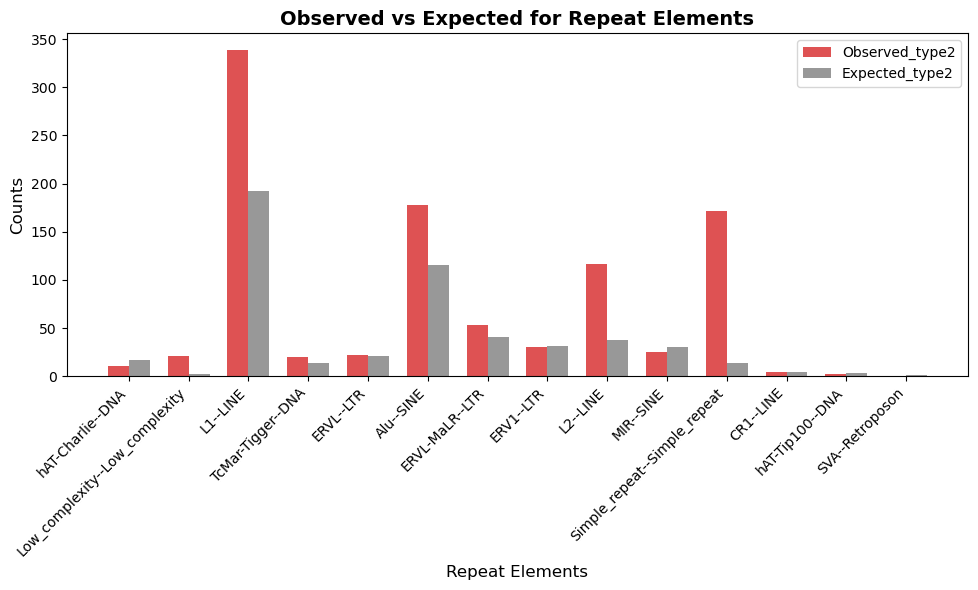

<Figure size 640x480 with 0 Axes>

In [211]:
# Set up the bar width and positions
x = np.arange(len(freq_df['repeat element']))  # X locations for the bars
width = 0.35  # Width of the bars

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the bars side by side
bars1 = ax.bar(x - width/2, freq_df['observed_type2'], width, label='Observed_type2', color='tab:red', alpha=0.8)
bars2 = ax.bar(x + width/2, freq_df['expected_type2'], width, label='Expected_type2', color='tab:grey', alpha=0.8)

# Add labels and title
ax.set_xlabel("Repeat Elements", fontsize=12)
ax.set_ylabel("Counts", fontsize=12)
ax.set_title("Observed vs Expected for Repeat Elements", fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(freq_df['repeat element'], rotation=45, ha='right')

# Add gridlines and legend
ax.legend()
# Show the plot
plt.tight_layout()
plt.show()
plt.savefig('repeat_element_type2.pdf')

In [193]:
i = 0
ct_tb = {}
for each in freq_df['repeat element']:
    observed_rest = freq_df[freq_df['repeat element'] != 'each']['observed_type2'].sum()
    expected_rest = freq_df[freq_df['repeat element'] != 'each']['expected_type2'].sum()
    observed = freq_df['observed_type2'][i]
    expected = freq_df['expected_type2'][i]
    ct_tb[each] = [[observed_rest,expected_rest],[observed,expected]]
    i += 1

In [196]:
p_value_list = []
for each in ct_tb:
    oddsratio, p_value = stats.fisher_exact(ct_tb[each])
    p_value_list.append([each,p_value])

In [200]:
p_value_df = pd.DataFrame(p_value_list)
p_value_df.columns = ['repeat element','p value type2']

In [203]:
freq_df = freq_df.merge(p_value_df,on='repeat element')

In [204]:
i = 0
ct_tb = {}
for each in freq_df['repeat element']:
    observed_rest = freq_df[freq_df['repeat element'] != 'each']['observed_type1'].sum()
    expected_rest = freq_df[freq_df['repeat element'] != 'each']['expected_type1'].sum()
    observed = freq_df['observed_type1'][i]
    expected = freq_df['expected_type1'][i]
    ct_tb[each] = [[observed_rest,expected_rest],[observed,expected]]
    i += 1
p_value_list = []
for each in ct_tb:
    oddsratio, p_value = stats.fisher_exact(ct_tb[each])
    p_value_list.append([each,p_value])
p_value_df = pd.DataFrame(p_value_list)
p_value_df.columns = ['repeat element','p value type1']

In [205]:
freq_df = freq_df.merge(p_value_df,on='repeat element')

In [207]:
freq_df.to_csv('repeat_element_freq.csv')

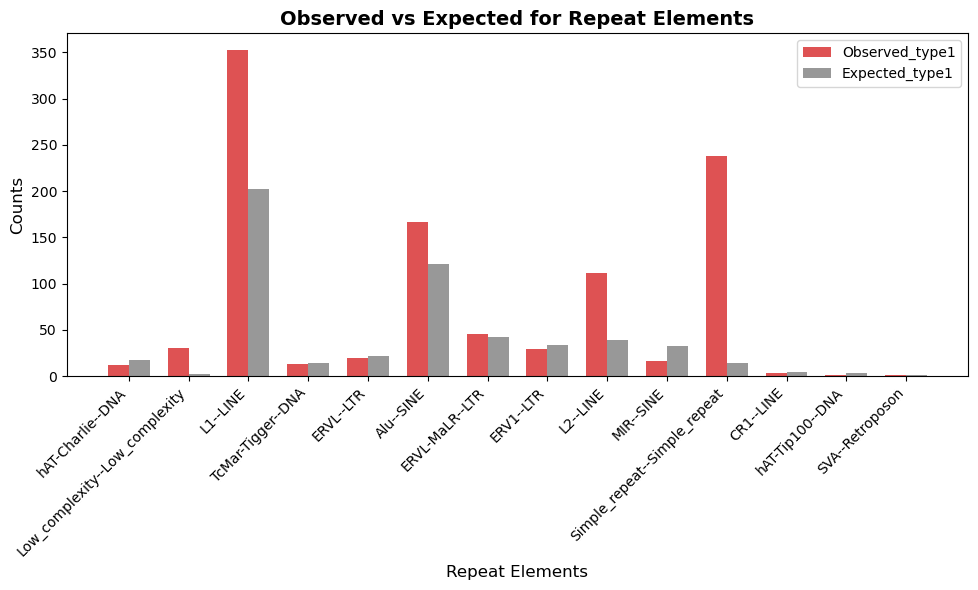

<Figure size 640x480 with 0 Axes>

In [210]:
# Set up the bar width and positions
x = np.arange(len(freq_df['repeat element']))  # X locations for the bars
width = 0.35  # Width of the bars

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the bars side by side
bars1 = ax.bar(x - width/2, freq_df['observed_type1'], width, label='Observed_type1', color='tab:red', alpha=0.8)
bars2 = ax.bar(x + width/2, freq_df['expected_type1'], width, label='Expected_type1', color='tab:grey', alpha=0.8)

# Add labels and title
ax.set_xlabel("Repeat Elements", fontsize=12)
ax.set_ylabel("Counts", fontsize=12)
ax.set_title("Observed vs Expected for Repeat Elements", fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(freq_df['repeat element'], rotation=45, ha='right')

# Add gridlines and legend
ax.legend()
# Show the plot
plt.tight_layout()
plt.show()
plt.savefig('repeat_element_type1.pdf')